
# Titanic Survival Prediction – Full Data Science Project

Workflow
1. Data loading
2. Data inspection
3. Exploratory Data Analysis
4. Feature engineering
5. Preprocessing
6. Model training
7. Cross validation
8. Feature importance
9. Model comparison
10. Ensemble prediction
11. Kaggle submission


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb


## Load Data

In [2]:

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Inspection

In [3]:

train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:

train_df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:

train_df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Exploratory Data Analysis

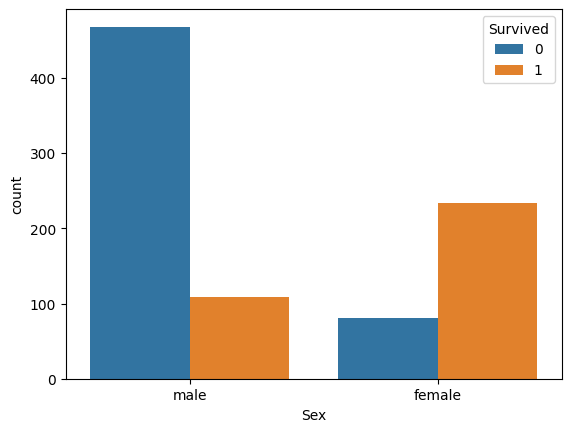

In [6]:

sns.countplot(data=train_df, x="Sex", hue="Survived")
plt.show()


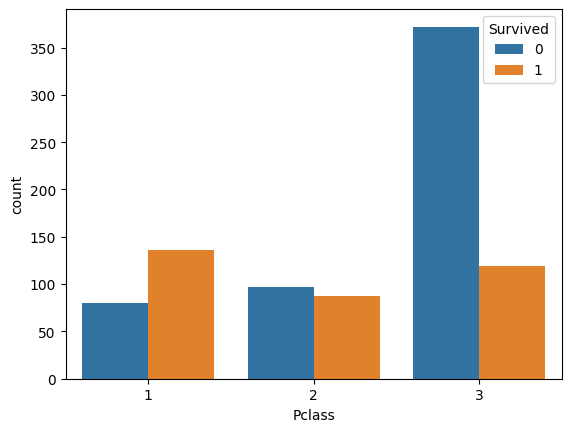

In [7]:

sns.countplot(data=train_df, x="Pclass", hue="Survived")
plt.show()


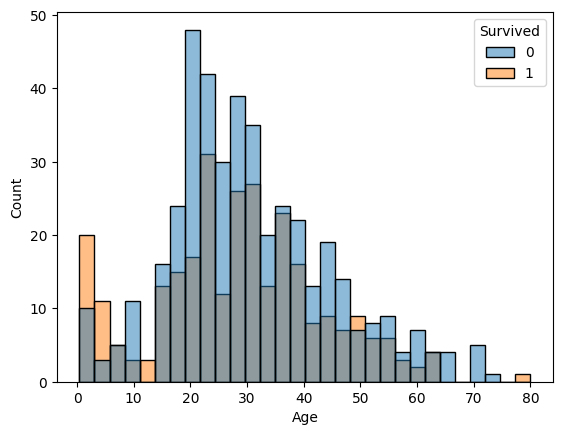

In [8]:

sns.histplot(data=train_df, x="Age", hue="Survived", bins=30)
plt.show()


## Feature Engineering

In [9]:

train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1
test_df["FamilySize"] = test_df["SibSp"] + test_df["Parch"] + 1

train_df["IsAlone"] = (train_df["FamilySize"] == 1).astype(int)
test_df["IsAlone"] = (test_df["FamilySize"] == 1).astype(int)


In [10]:

train_df["Title"] = train_df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
test_df["Title"] = test_df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)


<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_711/3983032413.py:1: SyntaxWarning: invalid escape sequence '\.'
  train_df["Title"] = train_df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
/tmp/ipykernel_711/3983032413.py:2: SyntaxWarning: invalid escape sequence '\.'
  test_df["Title"] = test_df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)


In [11]:

train_df["Age"] = train_df["Age"].fillna(train_df["Age"].median())
test_df["Age"] = test_df["Age"].fillna(test_df["Age"].median())

train_df["Embarked"] = train_df["Embarked"].fillna(train_df["Embarked"].mode()[0])
test_df["Embarked"] = test_df["Embarked"].fillna(test_df["Embarked"].mode()[0])

test_df["Fare"] = test_df["Fare"].fillna(test_df["Fare"].median())


## Encode Categorical Variables

In [12]:

categorical_cols = ["Sex", "Embarked", "Title"]

encoder = LabelEncoder()

for col in categorical_cols:
    train_df[col] = encoder.fit_transform(train_df[col])
    test_df[col] = encoder.fit_transform(test_df[col])


## Feature Selection

In [13]:

features = [
    "Pclass","Sex","Age","SibSp","Parch","Fare",
    "Embarked","FamilySize","IsAlone","Title"
]

X = train_df[features]
y = train_df["Survived"]
X_test = test_df[features]


## RandomForest Model

In [14]:

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf.fit(X,y)


RandomForestClassifier(max_depth=5, n_estimators=300, random_state=42)

## Cross Validation

In [15]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf, X, y, cv=cv)

print("CV Accuracy:", scores.mean())


CV Accuracy: 0.8293955181721172


## Feature Importance

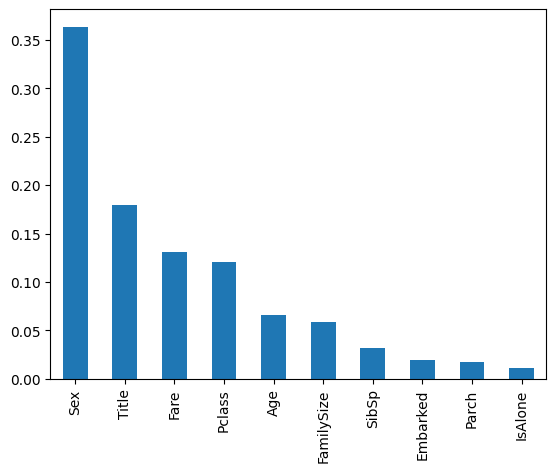

In [16]:

importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.plot(kind="bar")
plt.show()


## LightGBM Model

In [17]:

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05
)

lgb_model.fit(X,y)


[LightGBM] [Info] Number of positive: 342, number of negative: 549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000487 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 244
[LightGBM] [Info] Number of data points in the train set: 891, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383838 -> initscore=-0.473288
[LightGBM] [Info] Start training from score -0.473288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(learning_rate=0.05, n_estimators=500)

## Model Comparison

In [18]:

rf_score = cross_val_score(rf, X, y, cv=cv).mean()
lgb_score = cross_val_score(lgb_model, X, y, cv=cv).mean()

print("RandomForest:", rf_score)
print("LightGBM:", lgb_score)


[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 217
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

## Ensemble Prediction

In [19]:

rf_pred = rf.predict_proba(X_test)[:,1]
lgb_pred = lgb_model.predict_proba(X_test)[:,1]

ensemble_pred = (rf_pred + lgb_pred) / 2

final_pred = (ensemble_pred > 0.5).astype(int)


## Submission File

In [20]:

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": final_pred
})

submission.to_csv("submission.csv", index=False)

submission.head()


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1
